# The public registry's truncation bias

The public registry applies a confidentiality rule: a municipality with fewer than ten
installations does not appear in the published municipal view. Its capacity is not absent from the
registry. It is absent from the **public view at municipal granularity**, and it is still counted
in the departmental totals.

That single rule produces two reference series from one source:

- **Municipal, truncated**: the sum of the published municipalities. This is what a portal user
  obtains by aggregating the municipal view themselves.
- **Departmental, corrected**: the published departmental totals, on which the municipal
  censoring does not operate.

The audit is identical in both cases: same corrected estimate, same battery, same thresholds. The
difference between them therefore measures an artefact **of the reference**, not of the method.
That is the whole design of this notebook, and it is why the comparison is informative at all.

Only **under-reporting** is treated here. Correcting the truncation also produces over-reported
units, but those belong to a different artefact, the annual dating of the departmental totals, and
mixing the two would saturate the map without serving the argument.

## 0. Configuration and data

In [1]:
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
from matplotlib.patches import Patch


def _find_root(start, marker='paths.py'):
    for parent in [start, *start.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(marker)


ROOT = _find_root(Path.cwd())
sys.path.insert(0, str(ROOT))
import paths
sys.path.insert(0, str(ROOT / 'code' / '0_pipeline' / 'evaluation' / 'src'))
import helpers
import style
import units
style.apply()

FIGS_DIR = paths.FIGURES
FIG_PREFIX = 'truncation'

ADMIN = (ROOT / '0_data/src/admin-boundaries/ADMIN-EXPRESS_3-2__SHP_LAMB93_FXX_2025-02-03/'
         'ADMIN-EXPRESS/1_DONNEES_LIVRAISON_2025-02-00021/'
         'ADE_3-2_SHP_LAMB93_FXX-ED2025-02-03')

com = pd.read_csv(paths.COMPARISON_COMMUNES_RNI,
                  dtype={'code_insee': str, 'dpt': str, 'unit': str})
bu = pd.read_csv(paths.AUDIT_RNI_BOTTOMUP, dtype={'dpt': str})
ag = pd.read_csv(paths.AUDIT_RNI_AGG, dtype={'dpt': str})

dept_geo = units.dissolve_units(
    gpd.read_file(paths.DEPARTEMENTS_DETAILED))
if dept_geo.crs is not None and dept_geo.crs.to_epsg() != 4326:
    dept_geo = dept_geo.to_crs(4326)

print(f"{len(com):,} communes | {len(bu)} unites de report")

34,746 communes | 93 unites de report


## 1. Which municipalities does the rule remove?

A municipality counts as **censored** when the detector finds PV there and the published municipal
view reports zero capacity. The three other cases, capacity on both sides, capacity on neither, or
capacity in the registry with no detection, are not censoring and are left grey.

In [2]:
com['censored'] = (com.kWp_dpvm > 0) & (com.kWp_rni == 0)

tab = pd.crosstab(com.kWp_dpvm > 0, com.kWp_rni > 0)
tab.index.name, tab.columns.name = 'detection > 0', 'RNI communal > 0'
print(tab.to_string())

cens = com[com.censored]
print(f"\ncensored municipalities: {len(cens):,} "
      f"({len(cens) / len(com):.1%} of all municipalities)")
print(f"detected capacity they carry: {cens.kWp_dpvm.sum() / 1e3:,.0f} MWp, "
      f"{cens.kWp_dpvm.sum() / com.kWp_dpvm.sum():.1%} of the national detected total")
print(f"median population: {cens.population.median():,.0f} "
      f"against {com.loc[~com.censored, 'population'].median():,.0f} elsewhere")

# Censored share per reporting unit, for the manuscript text
by_unit = (com.groupby('unit')
           .apply(lambda g: g.loc[g.censored, 'kWp_dpvm'].sum() / g.kWp_dpvm.sum(),
                  include_groups=False)
           .rename('share_censored').reset_index())
print(f"\ncensored share per unit: median {by_unit.share_censored.median():.1%} | "
      f"max {by_unit.share_censored.max():.1%} "
      f"({by_unit.loc[by_unit.share_censored.idxmax(), 'unit']})")
print(f"units above 40%: {(by_unit.share_censored > 0.40).sum()}")
by_unit.to_csv(paths.TRUNCATION_SHARE, index=False)

RNI communal > 0  False  True 
detection > 0                 
False              2185      0
True              14019  18542

censored municipalities: 14,019 (40.3% of all municipalities)
detected capacity they carry: 363 MWp, 11.6% of the national detected total
median population: 211 against 873 elsewhere

censored share per unit: median 13.0% | max 100.0% (2A)
units above 40%: 11


## 2. Effect on the departmental diagnosis

Same audit, same corrected estimate, two references. A unit that loses its under-reporting flag
once the truncation is corrected is a unit whose flag was an artefact of the published view rather
than a defect of the registry.

In [3]:
status = (bu[['dpt', 'nom', 'status_kwp']].rename(columns={'status_kwp': 'truncated'})
          .merge(ag[['dpt', 'status_kwp']].rename(columns={'status_kwp': 'corrected'}), on='dpt'))

print(pd.crosstab(status.truncated, status.corrected, margins=True).to_string())

n_bu = (status.truncated == 'below').sum()
n_ag = (status.corrected == 'below').sum()
recovered = status[(status.truncated == 'below') & (status.corrected != 'below')]
print(f"\nunder-reported: {n_bu} units on the truncated view, {n_ag} after correction")
print(f"{len(recovered)} units lose their flag, "
      f"{len(recovered) / n_bu:.0%} of those flagged on the public view")
print('  ' + ', '.join(f"{r.nom} ({r.dpt})" for r in recovered.itertuples()))

persist = status[(status.truncated == 'below') & (status.corrected == 'below')]
print(f"\n{len(persist)} units stay under-reported under both views:")
print('  ' + ', '.join(f"{r.nom} ({r.dpt})" for r in persist.itertuples()))

status.to_csv(paths.TRUNCATION_STATUS, index=False)

corrected  above  below  within  All
truncated                           
above         12      0       0   12
below          0      8      24   32
within         9      0      40   49
All           21      8      64   93

under-reported: 32 units on the truncated view, 8 after correction
24 units lose their flag, 75% of those flagged on the public view
  Aisne (02), Ardennes (08), Aube (10), Aveyron (12), Calvados (14), Cantal (15), Charente (16), Côte-d'Or (21), Dordogne (24), Eure-et-Loir (28), Gers (32), Indre (36), Jura (39), Loir-et-Cher (41), Haute-Marne (52), Meuse (55), Nièvre (58), Orne (61), Sarthe (72), Seine-Maritime (76), Somme (80), Vienne (86), Vosges (88), Val-d'Oise (95)

8 units stay under-reported under both views:
  Corrèze (19), Creuse (23), Corse-du-Sud (2A), Haute-Corse (2B), Lozère (48), Haute-Saône (70), Paris + petite couronne (75PC), Territoire de Belfort (90)


### 2.1 Cross-check against the audit run on the connection data

The two registries are compiled independently, through different reporting chains, and the two
audits are independent too. If the units that survive the truncation correction turn out to be the
same units as the connection-data hard core, that agreement is observed rather than built in.
Nothing in the design forces it.

In [4]:
rb = pd.read_csv(paths.SPECS_RTE, dtype={'dpt': str})
hard_core = set(rb.loc[rb.hard_core_below, 'dpt'])
rni_below = set(status.loc[status.corrected == 'below', 'dpt'])

inter = rni_below & hard_core
print(f"connection-data hard core (below, A and B): {len(hard_core)} units")
print(f"public registry, corrected (below)       : {len(rni_below)} units")
print(f"intersection                             : {len(inter)} / {len(rni_below)}")
print(f"outside the hard core                    : {sorted(rni_below - hard_core) or 'none'}")
assert rni_below <= hard_core, 'a public-registry unit falls outside the connection-data hard core'
print("\nEvery under-reported unit of the corrected public registry lies inside the hard core")
print("established against the connection data. Two independently compiled references, two")
print("independent audits, no contradiction.")

connection-data hard core (below, A and B): 18 units
public registry, corrected (below)       : 8 units
intersection                             : 8 / 8
outside the hard core                    : none

Every under-reported unit of the corrected public registry lies inside the hard core
established against the connection data. Two independently compiled references, two
independent audits, no contradiction.


## 3. Figure

Three maps, from the cause to the diagnosis. The first shows the censoring itself, at the
granularity where it operates. The next two show what it does to the departmental audit, before
and after correction, keeping only the under-reporting side.

scale clipped at 64% (true max 100%)


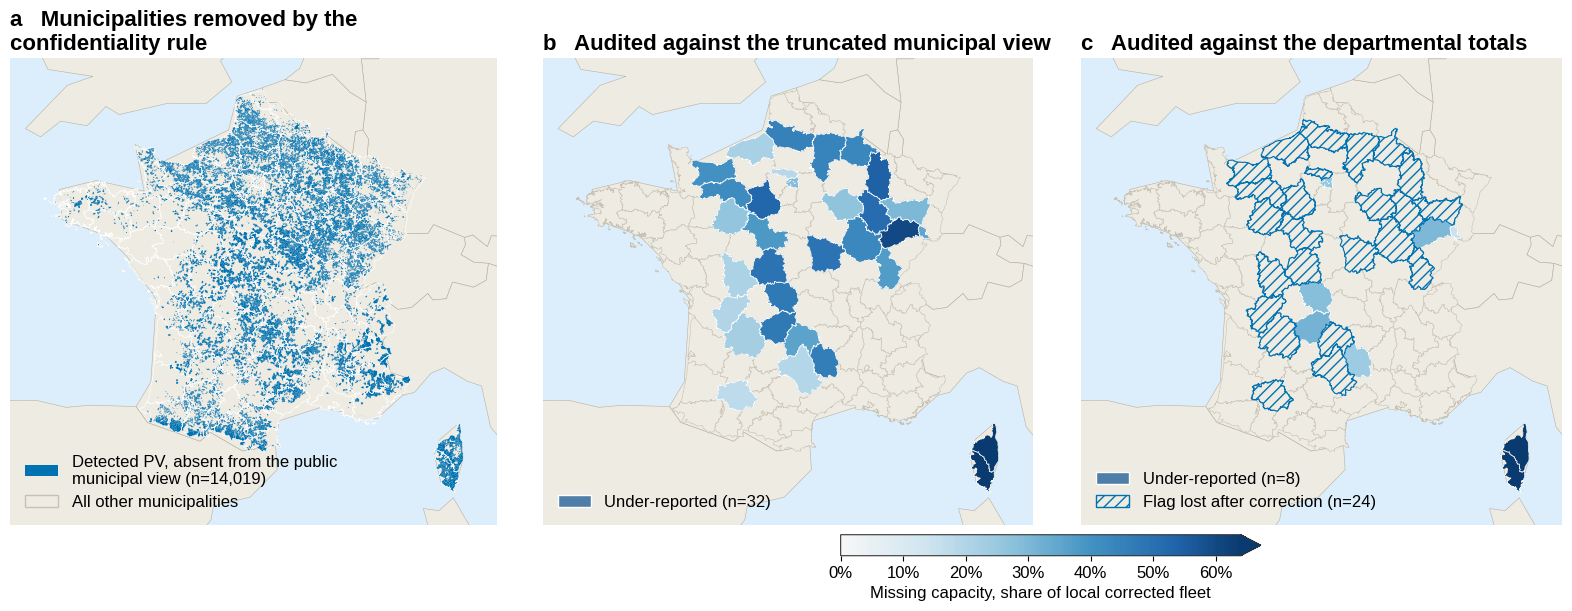

In [5]:
C_CENS = style.OKABE_ITO['blue']
C_BASE = '#eeebe3'
C_EDGE = '#c9c2b4'

# The same ramp as the fragmentation figure: the blue arm of a diverging map, so
# white at zero. Every unit here is on the same side, and a full diverging map
# would leave the red arm empty.
cmap_gap = mcolors.LinearSegmentedColormap.from_list(
    'below_arm', plt.cm.RdBu_r(np.linspace(0.5, 0.02, 256)))

# Gap as a share of the local corrected capacity, one column per variant
for src, tag in ((bu, 'truncated'), (ag, 'corrected')):
    src[f'gap_share_{tag}'] = (src.p_inst_mean - src.kWp_rte) / src.p_inst_mean
status = status.merge(bu[['dpt', 'gap_share_truncated']], on='dpt')
status = status.merge(ag[['dpt', 'gap_share_corrected']], on='dpt')

# One scale across both panels, because the change between them is what the
# reader is meant to see. Clipped at the 90th percentile: otherwise a single unit
# censored at 100% pulls the maximum to 1.0 and flattens every other contrast.
_gaps = pd.concat([status.loc[status.truncated == 'below', 'gap_share_truncated'],
                   status.loc[status.corrected == 'below', 'gap_share_corrected']])
vmax_gap = _gaps.quantile(0.90)
norm_gap = mcolors.Normalize(vmin=0, vmax=vmax_gap)
print(f"scale clipped at {vmax_gap:.0%} (true max {_gaps.max():.0%})")

# Municipal geometries, simplified to a 200 m tolerance. See paths.COMMUNES for
# why that is invisible at the scale this map is drawn.
gcom = gpd.read_file(paths.COMMUNES).rename(columns={'insee': 'INSEE_COM'})
gcom['code_insee'] = gcom['INSEE_COM'].astype(str).str.zfill(5)
gcom = gcom.to_crs(4326).merge(com[['code_insee', 'censored']], on='code_insee', how='left')
gcom['censored'] = gcom['censored'].fillna(False)

gdept = dept_geo.merge(status, left_on='code', right_on='dpt', how='left')

# Display only
FONT_TITLE = 16
FONT_OTHER = 12

fig, axes = plt.subplots(
    1, 3,
    figsize=(16, 6.0),
    layout='constrained'
)

# ---- (a) the censoring, at municipal granularity ----
ax = axes[0]

helpers.add_basemap(ax, dept_geo.total_bounds)
gcom.plot(ax=ax, facecolor=C_BASE, edgecolor='none', zorder=1)
gcom[gcom.censored].plot(ax=ax, facecolor=C_CENS, edgecolor='none', zorder=2)
dept_geo.boundary.plot(ax=ax, color='white', linewidth=0.4, zorder=3)

ax.legend(
    handles=[
        Patch(
            facecolor=C_CENS,
            edgecolor='none',
            label=f'Detected PV, absent from the public\n'
                  f'municipal view (n={int(gcom.censored.sum()):,})'
        ),
        Patch(
            facecolor=C_BASE,
            edgecolor=C_EDGE,
            label='All other municipalities'
        ),
    ],
    loc='lower left',
    fontsize=FONT_OTHER,
    frameon=False
)

ax.set_title(
    'a   Municipalities removed by the\nconfidentiality rule',
    fontweight='bold',
    fontsize=FONT_TITLE,
    loc='left'
)

helpers._hide_axis_chrome(ax)


# ---- (b) and (c) the departmental diagnosis ---------------------------
for ax, col, letter, title in (
    (
        axes[1],
        'truncated',
        'b',
        'Audited against the truncated municipal view'
    ),
    (
        axes[2],
        'corrected',
        'c',
        'Audited against the departmental totals'
    )
):

    helpers.add_basemap(ax, dept_geo.total_bounds)

    gdept.plot(
        ax=ax,
        facecolor=C_BASE,
        edgecolor=C_EDGE,
        linewidth=0.4,
        zorder=1
    )

    sel = gdept[gdept[col] == 'below']

    sel.plot(
        ax=ax,
        column=f'gap_share_{col}',
        cmap=cmap_gap,
        norm=norm_gap,
        edgecolor='white',
        linewidth=0.5,
        legend=False,
        zorder=2
    )

    handles = [
        Patch(
            facecolor='#4f7fa8',
            edgecolor='white',
            label=f'Under-reported (n={len(sel)})'
        )
    ]

    if col == 'corrected':
        rec = gdept[
            (gdept.truncated == 'below')
            & (gdept.corrected != 'below')
        ]

        rec.plot(
            ax=ax,
            facecolor='none',
            edgecolor=C_CENS,
            linewidth=0.8,
            hatch='///',
            zorder=3
        )

        handles.append(
            Patch(
                facecolor='none',
                edgecolor=C_CENS,
                hatch='///',
                label=f'Flag lost after correction (n={len(rec)})'
            )
        )

    ax.legend(
        handles=handles,
        loc='lower left',
        fontsize=FONT_OTHER,
        frameon=False
    )

    ax.set_title(
        f'{letter}   {title}',
        fontweight='bold',
        fontsize=FONT_TITLE,
        loc='left'
    )

    helpers._hide_axis_chrome(ax)


# ---- Colorbar -----------------------------------------------------------
sm = plt.cm.ScalarMappable(
    cmap=cmap_gap,
    norm=norm_gap
)

cb = fig.colorbar(
    sm,
    ax=list(axes[1:]),
    orientation='horizontal',
    fraction=0.045,
    pad=0.02,
    shrink=0.55,
    extend='max'
)

cb.set_label(
    'Missing capacity, share of local corrected fleet',
    fontsize=FONT_OTHER
)

cb.ax.xaxis.set_major_formatter(
    mticker.PercentFormatter(
        xmax=1,
        decimals=0
    )
)

cb.ax.tick_params(
    labelsize=FONT_OTHER
)

cb.cmap.set_over(cmap_gap(1.0))

helpers.save_fig(fig, f'{FIG_PREFIX}_public_registry.pdf', FIGS_DIR) 
plt.show()

## 4. What this establishes

The confidentiality rule removes roughly one municipality in three from the public municipal view,
and with them a substantial share of the detected capacity. The municipalities affected are the
smallest ones, which concentrates the censoring in rural areas.

The effect on an audit is large and runs in one direction only. Auditing the public registry as a
user would aggregate it from the municipal view produces three to four times as many
under-reported units as the same audit run on the departmental totals. Most of those flags are
publication artefacts, not registry defects.

A minority survives the correction. Those units are under-reported under both views, and therefore
independently of the censoring, and they are the only ones whose diagnosis implicates the registry
itself.

The consequence for a portal user is worth stating plainly: aggregating the published municipal
view does not reconstitute the registry, and the bias runs systematically downward. That is not a
limitation of the audit method. It is a property of the published data, which the audit makes
visible.